In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('heart-disease.csv')

In [3]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [4]:
df.shape

(303, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.drop_duplicates()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


<Axes: >

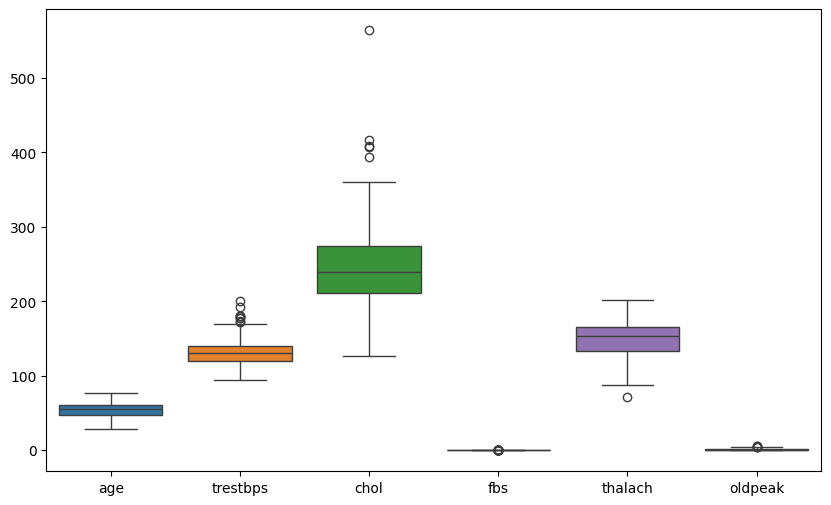

In [10]:
numaric_col = [
    'age',
    'trestbps',
    'chol',
    'fbs',
    'thalach',
    'oldpeak'
]

plt.figure(figsize=(10,6))
sns.boxplot(data=df[numaric_col])



trestbps, chol, and thalach contain outliers, but these values are medically plausible and were therefore retained in the dataset.

In [11]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

<Axes: xlabel='target', ylabel='count'>

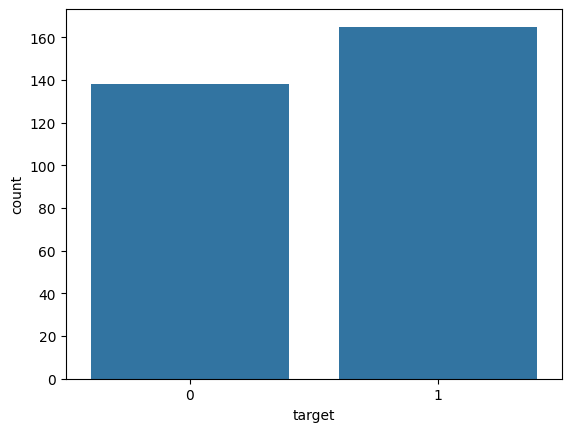

In [12]:
sns.countplot(data=df, x = 'target')

In [13]:
df.groupby('sex')['target'].mean()


sex
0    0.750000
1    0.449275
Name: target, dtype: float64

<Axes: xlabel='sex', ylabel='target'>

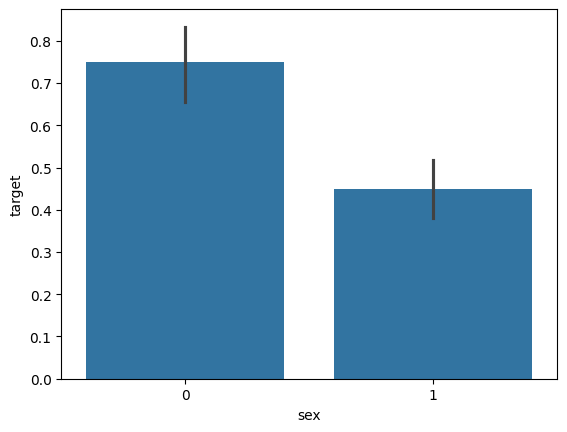

In [14]:
sns.barplot(
    data=df,
    x='sex',
    y='target'
)

In [15]:
df['age_group'] = pd.cut(
   df['age'],
   bins=[10,40,60,100],
   labels=['Young', 'Middle' ,'Old']
)

In [16]:
df.groupby('age_group')['target'].mean()

C:\Users\Computer\AppData\Local\Temp\ipykernel_48024\2017711513.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['target'].mean()


age_group
Young     0.684211
Middle    0.570732
Old       0.443038
Name: target, dtype: float64

<Axes: xlabel='age_group', ylabel='target'>

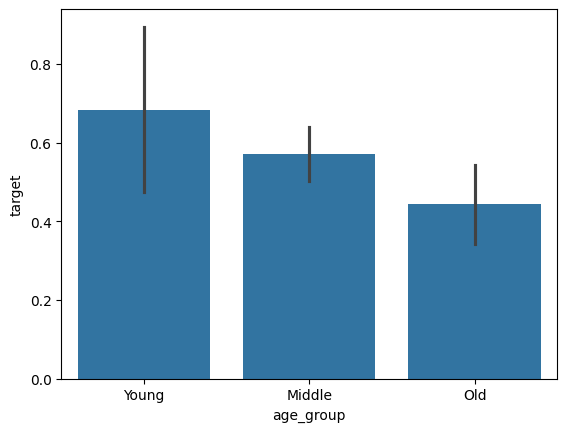

In [17]:
sns.barplot(
    data=df,
    x='age_group',
    y='target'
)

In [18]:
df.groupby('target')['chol'].mean()

target
0    251.086957
1    242.230303
Name: chol, dtype: float64

<Axes: xlabel='target', ylabel='chol'>

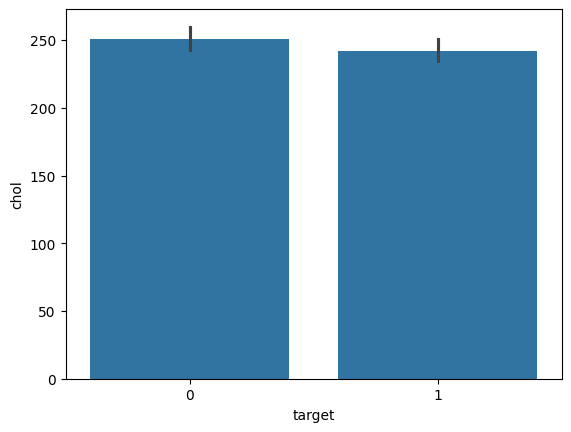

In [19]:
sns.barplot(
    data=df,
    x='target',
    y='chol'
)

<Axes: xlabel='target', ylabel='chol'>

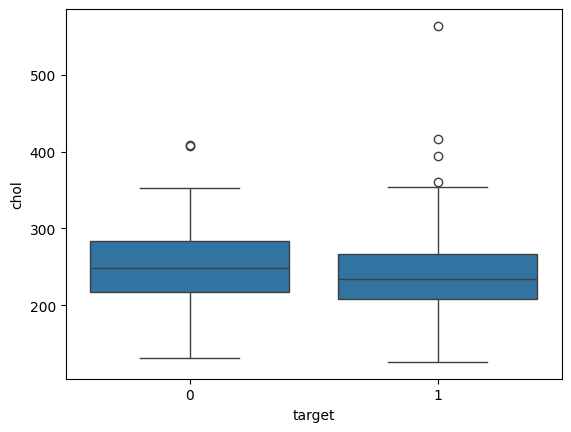

In [20]:
sns.boxplot(
    data=df,
    x='target',
    y='chol'
)

In [21]:
df.groupby('target')['trestbps'].mean()

target
0    134.398551
1    129.303030
Name: trestbps, dtype: float64

In [22]:
df.groupby('target')['thalach'].mean()

target
0    139.101449
1    158.466667
Name: thalach, dtype: float64

In [23]:
df.groupby('cp')['target'].mean()

cp
0    0.272727
1    0.820000
2    0.793103
3    0.695652
Name: target, dtype: float64

<Axes: xlabel='cp', ylabel='target'>

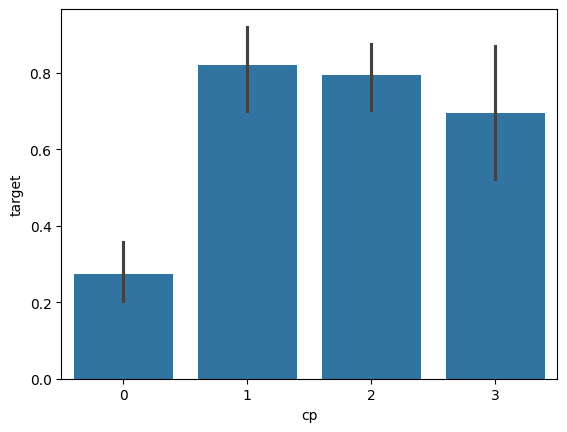

In [24]:
sns.barplot(
    data=df,
    x='cp',
    y='target'
)

In [25]:
df.groupby('target')['fbs'].mean()

target
0    0.159420
1    0.139394
Name: fbs, dtype: float64

In [26]:
df.groupby('restecg')['target'].mean()

restecg
0    0.462585
1    0.631579
2    0.250000
Name: target, dtype: float64

In [27]:
df.groupby('target')['exang'].mean()

target
0    0.550725
1    0.139394
Name: exang, dtype: float64

In [28]:
df.groupby('target')['oldpeak'].mean()

target
0    1.585507
1    0.583030
Name: oldpeak, dtype: float64

In [29]:
df.groupby('slope')['target'].mean()

slope
0    0.428571
1    0.350000
2    0.753521
Name: target, dtype: float64

In [30]:
df.groupby('target')['thal'].mean()

target
0    2.543478
1    2.121212
Name: thal, dtype: float64

In [31]:
corr=df.corr(numeric_only = True)

corr['target'].sort_values()

exang      -0.436757
oldpeak    -0.430696
ca         -0.391724
thal       -0.344029
sex        -0.280937
age        -0.225439
trestbps   -0.144931
chol       -0.085239
fbs        -0.028046
restecg     0.137230
slope       0.345877
thalach     0.421741
cp          0.433798
target      1.000000
Name: target, dtype: float64

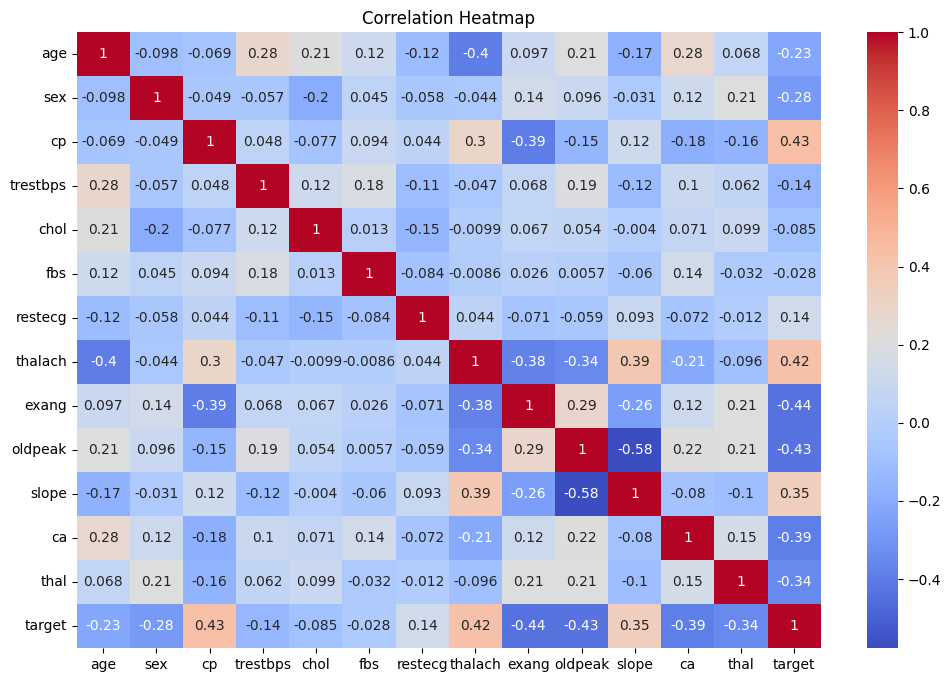

In [32]:
plt.figure(figsize=(12,8))


sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)


plt.title(
    "Correlation Heatmap"
)


plt.show()

In [33]:
insights = {
    
"Total Patients":
len(df),

"Heart Disease Patients":
df['target'].sum(),

"Average Age":
df['age'].mean(),

"Average Cholesterol":
df['chol'].mean(),

"Average Heart Rate":
df['thalach'].mean()

}


insights_df = pd.DataFrame(
    insights,
    index=[0]
)


insights_df

,Total Patients,Heart Disease Patients,Average Age,Average Cholesterol,Average Heart Rate
0,303,165,54.366337,246.264026,149.646865


In [34]:
df.to_csv("heart_cleaned.csv", index=False)

In [35]:
correlation = df.corr(numeric_only=True)['target'].drop('target')

correlation_df = correlation.reset_index()

correlation_df.columns = ['Feature', 'Correlation']

In [36]:
correlation_df.to_csv('correlation.csv', index=False)